## EDA & Dataförståelse
Visa datasetstorlek, datatyper och target-fördelning.
Kontrollera saknade värden och beskriv hur ni hanterar dem.
Minst 2 figurer/tabeller + kort tolkning.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [ ]:
df = pd.read_csv("historical_data.csv")
print("Datasetstorlek (rader, kolumner):", df.shape)
print("\nDatatyper:")
print(df.dtypes)
print("\nSammanfattning:")
print(df.info())


Datasetstorlek (rader, kolumner): (12000, 18)

Datatyper:
id                              int64
day                             int64
event_type                        str
category                          str
region                            str
device                            str
account_age_days              float64
num_prev_listings               int64
prev_reports_30d                int64
verification_level              int64
price                         float64
num_images                      int64
message_length                  int64
contains_off_platform           int64
urgency_words                   int64
payment_attempt                 int64
time_to_first_response_min    float64
is_suspicious                   int64
dtype: object

Sammanfattning:
<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id        

Datasetet innehåller 12.000st rader och 18st kolumner. Target-variabeln är is_suspicious som indikerar om en händelse i datasetet verkar misstänkt eller inte. Variabeln är av typen int64, som gör att värdet 0 innebär att händelsen inte är misstänkt, medans värdet 1 innebär att den är misstänkt.

In [ ]:
target_col = "is_suspicious"

print("Misstänkta värden (antal):")
print(df[target_col].value_counts())

print("\nMisstänkta värden (%):")
print(df[target_col].value_counts(normalize=True)* 100)

Misstänkta värden (antal):
is_suspicious
0    10776
1     1224
Name: count, dtype: int64

Misstänkta värden (%):
is_suspicious
0    89.8
1    10.2
Name: proportion, dtype: float64


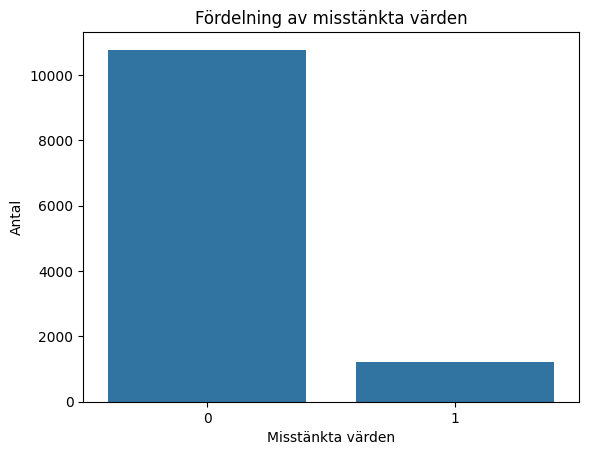

In [ ]:
plt.figure()
sns.countplot(x=df[target_col])
plt.title("Fördelning av misstänkta värden")
plt.xlabel("Misstänkta värden")
plt.ylabel("Antal")
plt.show()

Datasetet är obalanserat eftersom att majoriteten av observationerna, 89%, inte är misstänkta. Det är en mindre del, 10,2%, som kan klassificeras som misstänkta.

In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0]

print("Saknade värden per kolumn:")
print(missing)

Saknade värden per kolumn:
region                        340
price                         818
time_to_first_response_min    590
dtype: int64


Analysen visar att datasetet innehåller en mindre andel saknade värden i variablerna region, price och time_to_first_response_min. Största andelen finns i price. 
.... forts med hantering.

## Train/test + preprocessing
Skapa en train/test-split från historical_data.csv.
Bygg en pipeline där preprocessing sker på ett sätt som undviker att testdata påverkar träningen (undvik leakage).
För klassificering: använd gärna stratified split så klasserna fördelas rimligt.

## Modellering och jämförelse
Skapa en baseline.
Träna minst två ytterligare modeller (minst 3 totalt inkl baseline).
Utvärdera med rimlig metod (t.ex. cross-validation på train eller tydligt valideringsupplägg)
Välj metric och motivera valet utifrån ert kravkort.
(Exempel på modeller: LogisticRegression, DecisionTree, RandomForest, GradientBoosting…)

## Välj och optimera EN modell (hyperparameter-tuning)

Välj en “final” modell baserat på jämförelsen.
Gör tuning på den valda modellen (litet grid, minst 1–2 parametrar).
Förklara kort vad ni optimerade och varför (koppla till kravkortet).

## Threshold / prioritering (kopplat till kravkortet)

Ni måste bestämma hur modellen ska användas i praktiken. Välj en strategi:

A) Threshold-beslut
flagga misstänkt om proba ≥ t
motivera t utifrån kravkortet och visa konsekvenser (FP/FN eller precision/recall)
B) Top-X prioritering
flagga de X% högst risk (t.ex. top 5% eller top 50 per dag)
motivera X utifrån kravkortet och visa konsekvenser
Ni ska tydligt visa hur ert val påverkar FP/FN och varför det passar er stakeholder.

## Deploy-test: ny data (tisdag kursvecka 6)

När ni får new_data.csv ska ni:
använda er låsta pipeline
skapa prediktioner och en prioriteringslista